In [43]:
! pip install openpyxl



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# ==========================================
# CELL 1 — IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import json
import warnings

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")

In [2]:
# ==========================================
# CELL 2 — LOAD DATASETS
# ==========================================

inventory_df = pd.read_csv("inventory_transactions.csv")
production_df = pd.read_csv("production_orders.csv")
supplier_df = pd.read_csv("supplier_master.csv")
material_df = pd.read_csv("material_master.csv")
working_capital_df = pd.read_csv("working_capital_log.csv")
seasonal_df = pd.read_csv("seasonal_index.csv")

In [3]:
# ==========================================
# CELL 3 — CLEAN COLUMN NAMES
# VERY IMPORTANT
# ==========================================

all_dfs = [
    inventory_df,
    production_df,
    supplier_df,
    material_df,
    working_capital_df,
    seasonal_df
]

for df in all_dfs:

    df.columns = (
        df.columns
        .str.strip()
        .str.replace('\n', '', regex=False)
        .str.replace('\t', '', regex=False)
    )

In [4]:
# ==========================================
# CELL 4 — VERIFY COLUMNS
# ==========================================

print(material_df.columns.tolist())

['material_id', 'name', 'category', 'unit', 'reorder_point_current', 'current_stock', 'warehouse_location', 'substitute_material_ids']


In [5]:
# ==========================================
# CELL 5 — CONVERT DATES
# ==========================================

inventory_df['date'] = pd.to_datetime(inventory_df['date'])

production_df['delivery_date'] = pd.to_datetime(
    production_df['delivery_date']
)

In [6]:
# ==========================================
# CELL 6 — UNIT NORMALIZATION
# ==========================================

conversion_map = {
    'kg': 1,
    'kgs': 1,
    'roll': 50,
    'rolls': 50,
    'piece': 1,
    'pieces': 1
}

inventory_df['unit'] = (
    inventory_df['unit']
    .astype(str)
    .str.lower()
)

inventory_df['normalized_quantity'] = (
    inventory_df['quantity'] *
    inventory_df['unit'].map(conversion_map).fillna(1)
)

In [7]:
# ==========================================
# CELL 7 — PARSE BOM JSON
# ==========================================

production_df['material_bom'] = (
    production_df['material_bom']
    .apply(json.loads)
)

In [8]:
# ==========================================
# CELL 8 — EXPAND BOM INTO MATERIAL DEMAND
# ==========================================

material_demand = []

for _, row in production_df.iterrows():

    order_qty = row['quantity']

    bom = row['material_bom']

    delivery_date = row['delivery_date']

    for material_id, qty_per_unit in bom.items():

        total_needed = order_qty * qty_per_unit

        material_demand.append({
            'delivery_date': delivery_date,
            'material_id': material_id,
            'required_qty': total_needed
        })

demand_df = pd.DataFrame(material_demand)

In [9]:
# ==========================================
# CELL 9 — AGGREGATE DEMAND
# ==========================================

weekly_demand = demand_df.groupby(
    ['delivery_date', 'material_id']
)['required_qty'].sum().reset_index()

In [10]:
# ==========================================
# CELL 10 — ADD MONTH
# ==========================================

weekly_demand['month'] = (
    weekly_demand['delivery_date']
    .dt.month
)

In [11]:
# ==========================================
# CELL 11 — MERGE SEASONAL INDEX
# ==========================================

weekly_demand = weekly_demand.merge(
    seasonal_df,
    on='month',
    how='left'
)

In [12]:
# ==========================================
# CELL 12 — APPLY SEASONAL MULTIPLIER
# ==========================================

weekly_demand['seasonal_demand'] = (
    weekly_demand['required_qty'] *
    weekly_demand['fmcg_demand_multiplier']
)

In [13]:
# ==========================================
# CELL 13 — CREATE DATE FEATURES
# ==========================================

weekly_demand['day'] = (
    weekly_demand['delivery_date']
    .dt.day
)

weekly_demand['week'] = (
    weekly_demand['delivery_date']
    .dt.isocalendar()
    .week
)

weekly_demand['year'] = (
    weekly_demand['delivery_date']
    .dt.year
)

In [14]:
# ==========================================
# CELL 14 — ENCODE MATERIAL IDS
# ==========================================

weekly_demand['material_code'] = (
    weekly_demand['material_id']
    .astype('category')
    .cat.codes
)

In [15]:
# ==========================================
# CELL 15 — PREPARE FEATURES
# ==========================================

features = [
    'month',
    'day',
    'week',
    'year',
    'material_code',
    'fmcg_demand_multiplier'
]

X = weekly_demand[features]

y = weekly_demand['seasonal_demand']

In [16]:
# ==========================================
# CELL 16 — TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
# ==========================================
# CELL 17 — TRAIN MODEL
# ==========================================

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
# ==========================================
# CELL 18 — MODEL EVALUATION
# ==========================================

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 4917.75359689057


In [19]:
# ==========================================
# CELL 19 — PREDICT FUTURE DEMAND
# ==========================================

weekly_demand['predicted_demand'] = (
    model.predict(weekly_demand[features])
)

In [20]:
# ==========================================
# CELL 20 — CURRENT INVENTORY
# ==========================================

current_inventory = inventory_df.groupby(
    'material_id'
)['normalized_quantity'].sum().reset_index()

current_inventory.columns = [
    'material_id',
    'available_stock'
]

In [21]:
# ==========================================
# CELL 21 — MERGE INVENTORY
# ==========================================

procurement_df = material_df.merge(
    current_inventory,
    on='material_id',
    how='left'
)

procurement_df['available_stock'] = (
    procurement_df['available_stock']
    .fillna(0)
)

In [22]:
# ==========================================
# CELL 22 — FORECAST SUMMARY
# ==========================================

forecast_summary = weekly_demand.groupby(
    'material_id'
)['predicted_demand'].sum().reset_index()

In [23]:
# ==========================================
# CELL 23 — MERGE FORECAST
# ==========================================

procurement_df = procurement_df.merge(
    forecast_summary,
    on='material_id',
    how='left'
)

procurement_df['predicted_demand'] = (
    procurement_df['predicted_demand']
    .fillna(0)
)

In [24]:
# ==========================================
# CELL 24 — RECOMMENDED ORDER QUANTITY
# ==========================================

procurement_df['recommended_order_qty'] = (
    procurement_df['predicted_demand'] -
    procurement_df['available_stock']
)

procurement_df['recommended_order_qty'] = (
    procurement_df['recommended_order_qty']
    .apply(lambda x: max(0, x))
)

In [26]:
# ==========================================
# CELL 25 — GET PRIMARY SUPPLIER
# ==========================================

material_supplier_map = (
    inventory_df.groupby('material_id')['supplier_id']
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

procurement_df = procurement_df.merge(
    material_supplier_map,
    on='material_id',
    how='left'
)

procurement_df = procurement_df.merge(
    supplier_df[['supplier_id', 'moq']],
    on='supplier_id',
    how='left'
)

print(procurement_df.head())

  material_id                             name category   unit  \
0         M01  Kraft Paper - Grade A (180 GSM)    Paper  rolls   
1         M02  Kraft Paper - Grade B (150 GSM)    Paper  rolls   
2         M03  Kraft Paper - Grade C (120 GSM)    Paper  rolls   
3         M04                  White Top Liner    Paper  rolls   
4         M05               Corrugating Medium    Paper  rolls   

   reorder_point_current  current_stock warehouse_location  \
0                     40             18                 A1   
1                     30             55                 A2   
2                     20             62                 A3   
3                     15             30                 A4   
4                     25             44                 A5   

  substitute_material_ids  available_stock  predicted_demand  \
0                     M02       5241873.50      1.083496e+07   
1                     M01       4996062.44      5.564290e+06   
2                     NaN       549369

In [27]:
# ==========================================
# CELL 26 — APPLY MOQ ROUNDING
# ==========================================

procurement_df['final_order_qty'] = procurement_df.apply(
    lambda x:
    np.ceil(
        x['recommended_order_qty'] / x['moq']
    ) * x['moq']
    if pd.notnull(x['moq']) and x['moq'] > 0
    else x['recommended_order_qty'],
    axis=1
)

In [28]:
# ==========================================
# CELL 27 — UNIT PRICE
# ==========================================

latest_prices = inventory_df.groupby(
    'material_id'
)['unit_price'].mean().reset_index()

In [29]:
# ==========================================
# CELL 28 — MERGE PRICE
# ==========================================

procurement_df = procurement_df.merge(
    latest_prices,
    on='material_id',
    how='left'
)

In [30]:
# ==========================================
# CELL 29 — ESTIMATED COST
# ==========================================

procurement_df['estimated_cost'] = (
    procurement_df['final_order_qty'] *
    procurement_df['unit_price']
)

In [31]:
# ==========================================
# CELL 30 — WORKING CAPITAL CHECK
# ==========================================

latest_capital = working_capital_df.iloc[-1]

available_credit = (
    latest_capital['available_credit_inr']
)

procurement_df = procurement_df.sort_values(
    by='estimated_cost'
)

In [32]:
# ==========================================
# CELL 31 — SELECT VALID ORDERS
# ==========================================

selected_orders = []

running_total = 0

for _, row in procurement_df.iterrows():

    cost = row['estimated_cost']

    if running_total + cost <= available_credit:

        selected_orders.append(row)

        running_total += cost

final_orders_df = pd.DataFrame(selected_orders)

In [33]:
# ==========================================
# CELL 32 — DAYS OF STOCK
# ==========================================

procurement_df['days_of_stock'] = np.where(
    procurement_df['predicted_demand'] > 0,

    procurement_df['available_stock'] /
    (procurement_df['predicted_demand'] / 28),

    np.inf
)

In [34]:
# ==========================================
# CELL 33 — STOCKOUT ALERTS
# ==========================================

stockout_alerts = procurement_df[
    procurement_df['days_of_stock'] < 3
]

print(stockout_alerts[
    ['material_id', 'days_of_stock']
])

Empty DataFrame
Columns: [material_id, days_of_stock]
Index: []


In [35]:
# ==========================================
# CELL 34 — VERIFY COLUMN NAMES
# ==========================================

for col in material_df.columns:
    print(repr(col))

'material_id'
'name'
'category'
'unit'
'reorder_point_current'
'current_stock'
'warehouse_location'
'substitute_material_ids'


In [38]:
# ==========================================
# CELL 35 — SUBSTITUTION LOGIC
# ==========================================

critical_materials = stockout_alerts.merge(
    material_df[
        ['material_id', 'substitute_material_ids']
    ],
    on='material_id',
    how='left',
    suffixes=('', '_extra')
)

print(
    critical_materials[
        ['material_id', 'substitute_material_ids']
    ]
)

Empty DataFrame
Columns: [material_id, substitute_material_ids]
Index: []


In [39]:
print(
    procurement_df[
        [
            'material_id',
            'available_stock',
            'predicted_demand',
            'days_of_stock'
        ]
    ].head(20)
)

   material_id  available_stock  predicted_demand  days_of_stock
2          M03       5493694.37      0.000000e+00            inf
11         M12        108685.59      4.896798e+04      62.146666
12         M13       4945592.12      2.675660e+06      51.754176
13         M14       4799205.03      2.698140e+06      49.803838
10         M11        117819.73      1.569135e+05      21.024019
9          M10        108438.38      1.868178e+05      16.252598
8          M09        105604.17      1.853970e+05      15.949106
6          M07        113703.47      2.542883e+05      12.520028
5          M06        111865.25      6.689558e+05       4.682263
1          M02       4996062.44      5.564290e+06      25.140627
7          M08        105694.70      8.361507e+05       3.539376
3          M04       4747616.83      6.117837e+06      21.728804
0          M01       5241873.50      1.083496e+07      13.546199
4          M05       5089071.75      1.545705e+07       9.218704


In [40]:
# ==========================================
# CELL 36 — SPLIT SUBSTITUTE MATERIALS
# ==========================================

critical_materials['substitute_list'] = (
    critical_materials['substitute_material_ids']
    .fillna('')
    .apply(lambda x: x.split(','))
)

In [41]:
# ==========================================
# CELL 37 — FINAL REPORT
# ==========================================

report_columns = [
    'material_id',
    'name',
    'available_stock',
    'predicted_demand',
    'final_order_qty',
    'estimated_cost'
]

weekly_report = procurement_df[
    report_columns
]

In [42]:
# ==========================================
# CELL 38 — SAVE CSV REPORT
# ==========================================

weekly_report.to_csv(
    "Weekly_Purchase_Recommendation.csv",
    index=False
)

print("CSV Report Generated Successfully")

CSV Report Generated Successfully


In [45]:
# ==========================================
# CELL 40 — SAVE MODEL
# ==========================================

import joblib

joblib.dump(
    model,
    "inventory_forecasting_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


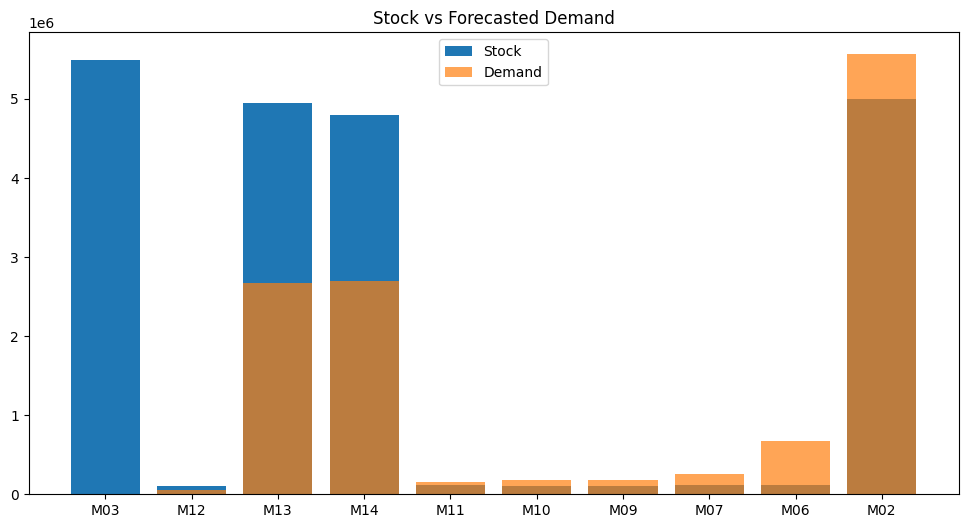

In [46]:
import matplotlib.pyplot as plt

top_materials = procurement_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_materials['material_id'],
    top_materials['available_stock'],
    label='Stock'
)

plt.bar(
    top_materials['material_id'],
    top_materials['predicted_demand'],
    alpha=0.7,
    label='Demand'
)

plt.legend()

plt.title("Stock vs Forecasted Demand")

plt.show()

ValueError: Wedge sizes 'x' must be non negative values

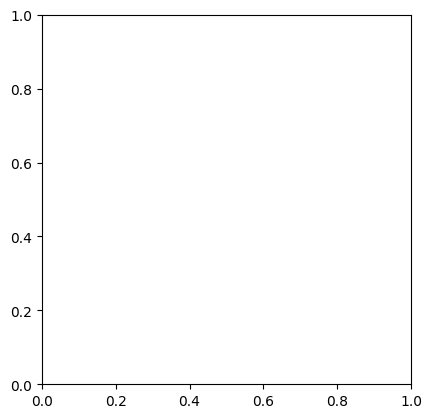

In [47]:
used_credit = procurement_df['estimated_cost'].sum()

remaining_credit = (
    available_credit - used_credit
)

plt.pie(
    [used_credit, remaining_credit],
    labels=['Used', 'Remaining'],
    autopct='%1.1f%%'
)

plt.title("Working Capital Utilization")

plt.show()